# 02 · QUBO y líneas base clásicas

Formula y verifica la QUBO de Max-Cut; compara fuerza bruta, greedy,
recocido simulado y Goemans–Williamson sobre las mismas cuatro instancias.

In [1]:
from pathlib import Path
from itertools import product
import time

import cvxpy as cp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 2026
TAMANOS = (6, 8, 10, 12)
REINICIOS_GREEDY = 100
REDONDEOS_GW = 1000

candidatos = [
    Path.cwd(),
    Path.cwd().parent,
    Path.home() / "quantathon_reto1_red_ice",
]

ROOT = next(
    ruta for ruta in candidatos
    if (ruta / "config.yaml").exists()
    and (ruta / "resultados").exists()
)

SALIDAS = ROOT / "resultados" / "clasicos"
FIGURAS = ROOT / "figuras"

SALIDAS.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(parents=True, exist_ok=True)

print("Raíz:", ROOT.resolve())
print("CVXPY:", cp.__version__)
print("Solvers disponibles:", cp.installed_solvers())

assert "SCS" in cp.installed_solvers(), (
    "Falta el solver SCS. Ejecuta en una terminal: "
    "python -m pip install cvxpy scs"
)

Raíz: /home/jovyan/reto1_qaoa_noir
CVXPY: 1.9.2
Solvers disponibles: ['CLARABEL', 'SCS', 'SCIPY', 'HIGHS', 'GLOP', 'PDLP', 'OSQP']


### cargar los cuatro grafos

In [2]:
def clave(valor):
    if pd.isna(valor):
        return None

    if isinstance(valor, float) and valor.is_integer():
        return str(int(valor))

    return str(valor).strip()


def cargar_grafo(n):
    ruta = ROOT / "datos" / "grafos" / f"grafo_{n}_aristas.csv"
    aristas = pd.read_csv(ruta)

    requeridas = {"source_id", "target_id", "weight"}
    faltantes = requeridas - set(aristas.columns)

    if faltantes:
        raise KeyError(
            f"Faltan columnas en {ruta.name}: {sorted(faltantes)}"
        )

    G = nx.Graph()

    for _, fila in aristas.iterrows():
        u = clave(fila["source_id"])
        v = clave(fila["target_id"])
        peso = float(fila["weight"])

        if G.has_edge(u, v):
            G[u][v]["weight"] += peso
        else:
            G.add_edge(u, v, weight=peso)

    assert G.number_of_nodes() == n
    assert nx.is_connected(G)
    assert all(
        datos["weight"] > 0
        for _, _, datos in G.edges(data=True)
    )

    return G


grafos = {
    n: cargar_grafo(n)
    for n in TAMANOS
}

resumen_carga = pd.DataFrame([
    {
        "n": n,
        "nodos": G.number_of_nodes(),
        "aristas": G.number_of_edges(),
        "peso_total": G.size(weight="weight"),
        "conectado": nx.is_connected(G),
        "arbol": nx.is_tree(G),
    }
    for n, G in grafos.items()
])

display(resumen_carga)

,n,nodos,aristas,peso_total,conectado,arbol
0,6,6,5,38.301790,True,True
1,8,8,7,42.218037,True,True
2,10,10,9,87.075048,True,True
3,12,12,11,93.299621,True,True


### función objetivo y matriz QUBO

In [3]:
def valor_corte_bits(G, nodos, bits):
    indice = {
        nodo: posicion
        for posicion, nodo in enumerate(nodos)
    }

    return float(sum(
        datos["weight"]
        for u, v, datos in G.edges(data=True)
        if bits[indice[u]] != bits[indice[v]]
    ))


def construir_qubo_maxcut(G):
    nodos = list(G.nodes())
    indice = {
        nodo: posicion
        for posicion, nodo in enumerate(nodos)
    }

    Q = np.zeros((len(nodos), len(nodos)), dtype=float)

    for u, v, datos in G.edges(data=True):
        i = indice[u]
        j = indice[v]
        w = float(datos["weight"])

        Q[i, i] -= w
        Q[j, j] -= w
        Q[i, j] += w
        Q[j, i] += w

    return Q, nodos


qubos = {}
orden_nodos = {}

for n, G in grafos.items():
    Q, nodos = construir_qubo_maxcut(G)

    qubos[n] = Q
    orden_nodos[n] = nodos

    pd.DataFrame(
        Q,
        index=nodos,
        columns=nodos,
    ).to_csv(SALIDAS / f"matriz_qubo_g{n}.csv")

print("Matrices QUBO construidas y guardadas.")

Matrices QUBO construidas y guardadas.


In [4]:
def valor_corte_bits(G, nodos, bits):
    indice = {
        nodo: posicion
        for posicion, nodo in enumerate(nodos)
    }

    return float(sum(
        datos["weight"]
        for u, v, datos in G.edges(data=True)
        if bits[indice[u]] != bits[indice[v]]
    ))


def construir_qubo_maxcut(G):
    nodos = list(G.nodes())
    indice = {
        nodo: posicion
        for posicion, nodo in enumerate(nodos)
    }

    Q = np.zeros((len(nodos), len(nodos)), dtype=float)

    for u, v, datos in G.edges(data=True):
        i = indice[u]
        j = indice[v]
        w = float(datos["weight"])

        Q[i, i] -= w
        Q[j, j] -= w
        Q[i, j] += w
        Q[j, i] += w

    return Q, nodos


qubos = {}
orden_nodos = {}

for n, G in grafos.items():
    Q, nodos = construir_qubo_maxcut(G)

    qubos[n] = Q
    orden_nodos[n] = nodos

    pd.DataFrame(
        Q,
        index=nodos,
        columns=nodos,
    ).to_csv(SALIDAS / f"matriz_qubo_g{n}.csv")

print("Matrices QUBO construidas y guardadas.")

Matrices QUBO construidas y guardadas.


### verificación exhaustiva del QUBO

In [5]:
verificacion_g6 = []
resumen_verificacion = []

for n, G in grafos.items():
    Q = qubos[n]
    nodos = orden_nodos[n]

    error_maximo = 0.0
    asignaciones = 0

    for bits_tupla in product((0, 1), repeat=n):
        bits = np.asarray(bits_tupla, dtype=float)

        valor_qubo = float(bits @ Q @ bits)
        valor_maxcut = valor_corte_bits(
            G,
            nodos,
            bits.astype(int),
        )

        error = abs(valor_qubo + valor_maxcut)
        error_maximo = max(error_maximo, error)
        asignaciones += 1

        assert np.isclose(
            valor_qubo,
            -valor_maxcut,
            atol=1e-8,
        )

        if n == 6:
            verificacion_g6.append({
                "bitstring": "".join(
                    str(int(bit)) for bit in bits
                ),
                "valor_qubo": valor_qubo,
                "valor_maxcut": valor_maxcut,
                "suma_debe_ser_cero":
                    valor_qubo + valor_maxcut,
            })

    resumen_verificacion.append({
        "n": n,
        "asignaciones_verificadas": asignaciones,
        "error_maximo": error_maximo,
        "resultado": "OK",
    })

df_verificacion_g6 = pd.DataFrame(verificacion_g6)
df_resumen_verificacion = pd.DataFrame(resumen_verificacion)

df_verificacion_g6.to_csv(
    SALIDAS / "verificacion_qubo_g6.csv",
    index=False,
)

display(df_resumen_verificacion)

print("Verificación QUBO exhaustiva: OK")

,n,asignaciones_verificadas,error_maximo,resultado
0,6,64,3.552714e-15,OK
1,8,256,7.105427e-15,OK
2,10,1024,1.421085e-14,OK
3,12,4096,1.421085e-14,OK


Verificación QUBO exhaustiva: OK


### solución exacta por fuerza bruta

In [6]:
def resolver_exacto(G, nodos):
    mejor_valor = -np.inf
    mejores_bits = []
    evaluaciones = 0

    # Se fija el primer bit para eliminar soluciones complementarias.
    for resto in product((0, 1), repeat=len(nodos) - 1):
        bits = np.asarray((0,) + resto, dtype=int)
        valor = valor_corte_bits(G, nodos, bits)
        evaluaciones += 1

        if valor > mejor_valor + 1e-9:
            mejor_valor = valor
            mejores_bits = [bits.copy()]
        elif np.isclose(valor, mejor_valor):
            mejores_bits.append(bits.copy())

    return {
        "optimo_exacto": float(mejor_valor),
        "bitstring": "".join(
            str(int(bit)) for bit in mejores_bits[0]
        ),
        "numero_soluciones_sin_complementos":
            len(mejores_bits),
        "evaluaciones": evaluaciones,
    }


filas_exactas = []

for n, G in grafos.items():
    inicio = time.perf_counter()
    resultado = resolver_exacto(G, orden_nodos[n])
    duracion = time.perf_counter() - inicio
    peso_total = float(G.size(weight="weight"))

    filas_exactas.append({
        "n": n,
        "peso_total": peso_total,
        **resultado,
        "razon_optima":
            resultado["optimo_exacto"] / peso_total,
        "runtime_seconds": duracion,
    })

df_exactos = pd.DataFrame(filas_exactas)
display(df_exactos)

assert np.allclose(
    df_exactos["optimo_exacto"],
    df_exactos["peso_total"],
)

print("Óptimos exactos confirmados.")

,n,peso_total,optimo_exacto,bitstring,numero_soluciones_sin_complementos,evaluaciones,razon_optima,runtime_seconds
0,6,38.301790,38.301790,011101,1,32,1.0,0.000908
1,8,42.218037,42.218037,01110010,1,128,1.0,0.003624
2,10,87.075048,87.075048,0111100010,1,512,1.0,0.019194
3,12,93.299621,93.299621,011110001010,1,2048,1.0,0.089507


Óptimos exactos confirmados.


### greedy con 100 reinicios

In [7]:
def busqueda_local_greedy(G, nodos, seed):
    rng = np.random.default_rng(seed)
    bits = rng.integers(0, 2, size=len(nodos), dtype=int)

    valor_actual = valor_corte_bits(G, nodos, bits)
    movimientos = 0

    while True:
        mejor_ganancia = 0.0
        mejores_movimientos = []

        for posicion in range(len(nodos)):
            candidato = bits.copy()
            candidato[posicion] ^= 1

            valor_candidato = valor_corte_bits(
                G,
                nodos,
                candidato,
            )
            ganancia = valor_candidato - valor_actual

            if ganancia > mejor_ganancia + 1e-12:
                mejor_ganancia = ganancia
                mejores_movimientos = [
                    (posicion, valor_candidato)
                ]
            elif (
                ganancia > 1e-12
                and np.isclose(ganancia, mejor_ganancia)
            ):
                mejores_movimientos.append(
                    (posicion, valor_candidato)
                )

        if not mejores_movimientos:
            break

        seleccion = rng.integers(len(mejores_movimientos))
        posicion, valor_actual = mejores_movimientos[seleccion]

        bits[posicion] ^= 1
        movimientos += 1

    return float(valor_actual), bits, movimientos


ejecuciones_greedy = []

for n, G in grafos.items():
    nodos = orden_nodos[n]

    for reinicio in range(REINICIOS_GREEDY):
        seed_ejecucion = SEED + n * 10_000 + reinicio
        inicio = time.perf_counter()

        valor, bits, movimientos = busqueda_local_greedy(
            G,
            nodos,
            seed_ejecucion,
        )

        ejecuciones_greedy.append({
            "n": n,
            "reinicio": reinicio,
            "seed": seed_ejecucion,
            "valor_corte": valor,
            "bitstring": "".join(map(str, bits)),
            "movimientos": movimientos,
            "runtime_seconds":
                time.perf_counter() - inicio,
        })

df_greedy = pd.DataFrame(ejecuciones_greedy)

df_greedy.to_csv(
    SALIDAS / "ejecuciones_greedy.csv",
    index=False,
)

display(
    df_greedy.groupby("n")["valor_corte"]
    .agg(["mean", "std", "max", "min"])
)

,mean,std,max,min
n,,,,
6,37.897341,1.481623,38.301790,32.523957
8,41.120249,2.278068,42.218037,36.440205
10,83.581639,4.247351,87.075048,69.474459
12,89.939764,3.806259,93.299621,75.699032


### recocido simulado

In [8]:
EJECUCIONES_RECOCIDO = 100
PASOS_RECOCIDO = 2_000


def recocido_simulado(
    G,
    nodos,
    seed,
    pasos=2_000,
):
    rng = np.random.default_rng(seed)

    bits = rng.integers(
        0,
        2,
        size=len(nodos),
        dtype=int,
    )

    valor_actual = valor_corte_bits(G, nodos, bits)

    mejores_bits = bits.copy()
    mejor_valor = valor_actual

    # Escala la temperatura según los pesos reales del grafo.
    grados_ponderados = dict(G.degree(weight="weight"))

    temperatura_inicial = max(
        float(valor)
        for valor in grados_ponderados.values()
    )

    temperatura_inicial = max(
        temperatura_inicial,
        1e-9,
    )

    temperatura_final = temperatura_inicial * 1e-3

    factor_enfriamiento = (
        temperatura_final / temperatura_inicial
    ) ** (1 / max(pasos - 1, 1))

    temperatura = temperatura_inicial
    movimientos_aceptados = 0
    movimientos_peores_aceptados = 0

    for _ in range(pasos):
        posicion = int(rng.integers(len(nodos)))

        candidato = bits.copy()
        candidato[posicion] ^= 1

        valor_candidato = valor_corte_bits(
            G,
            nodos,
            candidato,
        )

        diferencia = valor_candidato - valor_actual

        aceptar = (
            diferencia >= 0
            or rng.random()
            < np.exp(diferencia / temperatura)
        )

        if aceptar:
            bits = candidato
            valor_actual = valor_candidato
            movimientos_aceptados += 1

            if diferencia < 0:
                movimientos_peores_aceptados += 1

            if valor_actual > mejor_valor + 1e-12:
                mejor_valor = valor_actual
                mejores_bits = bits.copy()

        temperatura *= factor_enfriamiento

    return {
        "mejor_valor": float(mejor_valor),
        "mejor_bitstring": "".join(
            str(int(bit))
            for bit in mejores_bits
        ),
        "valor_final": float(valor_actual),
        "bitstring_final": "".join(
            str(int(bit))
            for bit in bits
        ),
        "movimientos_aceptados":
            movimientos_aceptados,
        "movimientos_peores_aceptados":
            movimientos_peores_aceptados,
        "temperatura_inicial":
            temperatura_inicial,
        "temperatura_final":
            temperatura,
    }


ejecuciones_recocido = []

for n, G in grafos.items():
    nodos = orden_nodos[n]

    for ejecucion in range(EJECUCIONES_RECOCIDO):
        seed_ejecucion = (
            SEED
            + n * 1_000_000
            + ejecucion
        )

        inicio = time.perf_counter()

        resultado = recocido_simulado(
            G,
            nodos,
            seed=seed_ejecucion,
            pasos=PASOS_RECOCIDO,
        )

        ejecuciones_recocido.append({
            "n": n,
            "ejecucion": ejecucion,
            "seed": seed_ejecucion,
            "pasos": PASOS_RECOCIDO,
            **resultado,
            "runtime_seconds":
                time.perf_counter() - inicio,
        })


df_recocido = pd.DataFrame(
    ejecuciones_recocido
)

df_recocido.to_csv(
    SALIDAS / "ejecuciones_recocido_simulado.csv",
    index=False,
)

display(
    df_recocido.groupby("n")["mejor_valor"]
    .agg(["mean", "std", "max", "min"])
)

print(
    "Resultados guardados en:",
    SALIDAS / "ejecuciones_recocido_simulado.csv",
)

,mean,std,max,min
n,,,,
6,38.301790,0.000000,38.301790,38.301790
8,42.218037,0.000000,42.218037,42.218037
10,87.075048,0.000000,87.075048,87.075048
12,93.206748,0.420945,93.299621,90.652929


Resultados guardados en: /home/jovyan/reto1_qaoa_noir/resultados/clasicos/ejecuciones_recocido_simulado.csv


### Goemans–Williamson

In [9]:
def goemans_williamson(
    G,
    nodos,
    redondeos=1000,
    seed=2026,
):
    n = len(nodos)
    indice = {
        nodo: posicion
        for posicion, nodo in enumerate(nodos)
    }

    X = cp.Variable((n, n), symmetric=True)

    terminos = [
        float(datos["weight"]) * (1 - X[indice[u], indice[v]])
        for u, v, datos in G.edges(data=True)
    ]

    problema = cp.Problem(
        cp.Maximize(0.5 * cp.sum(terminos)),
        [
            X >> 0,
            cp.diag(X) == 1,
        ],
    )

    inicio_sdp = time.perf_counter()

    problema.solve(
        solver=cp.SCS,
        eps=1e-6,
        max_iters=20_000,
        verbose=False,
    )

    runtime_sdp = time.perf_counter() - inicio_sdp

    assert problema.status in {
        cp.OPTIMAL,
        cp.OPTIMAL_INACCURATE,
    }, f"Estado inesperado: {problema.status}"

    X_valor = np.asarray(X.value, dtype=float)
    X_valor = (X_valor + X_valor.T) / 2

    valores_propios, vectores_propios = np.linalg.eigh(X_valor)
    valores_propios = np.clip(valores_propios, 0, None)

    V = (
        vectores_propios
        @ np.diag(np.sqrt(valores_propios))
    )

    normas = np.linalg.norm(V, axis=1, keepdims=True)
    V = V / np.where(normas > 1e-12, normas, 1.0)

    rng = np.random.default_rng(seed)
    resultados = []

    for redondeo in range(redondeos):
        hiperplano = rng.normal(size=n)
        signos = np.where(V @ hiperplano >= 0, 1, -1)
        bits = (signos < 0).astype(int)

        resultados.append({
            "redondeo": redondeo,
            "valor_corte":
                valor_corte_bits(G, nodos, bits),
            "bitstring": "".join(map(str, bits)),
        })

    return {
        "estado_sdp": problema.status,
        "limite_sdp": float(problema.value),
        "runtime_sdp": runtime_sdp,
        "resultados": resultados,
    }


ejecuciones_gw = []
resumen_sdp = []

for n, G in grafos.items():
    seed_gw = SEED + n * 100_000

    resultado = goemans_williamson(
        G,
        orden_nodos[n],
        redondeos=REDONDEOS_GW,
        seed=seed_gw,
    )

    resumen_sdp.append({
        "n": n,
        "estado_sdp": resultado["estado_sdp"],
        "limite_sdp": resultado["limite_sdp"],
        "runtime_sdp": resultado["runtime_sdp"],
    })

    for fila in resultado["resultados"]:
        ejecuciones_gw.append({
            "n": n,
            "seed": seed_gw,
            **fila,
        })

df_gw = pd.DataFrame(ejecuciones_gw)
df_sdp = pd.DataFrame(resumen_sdp)

df_gw.to_csv(
    SALIDAS / "ejecuciones_goemans_williamson.csv",
    index=False,
)

df_sdp.to_csv(
    SALIDAS / "resumen_sdp.csv",
    index=False,
)

display(df_sdp)

display(
    df_gw.groupby("n")["valor_corte"]
    .agg(["mean", "std", "max", "min"])
)

,n,estado_sdp,limite_sdp,runtime_sdp
0,6,optimal,38.301832,0.036768
1,8,optimal,42.218038,0.032491
2,10,optimal,87.075056,0.041501
3,12,optimal,93.299621,0.040868


,mean,std,max,min
n,,,,
6,38.301790,0.0,38.301790,38.301790
8,42.218037,0.0,42.218037,42.218037
10,87.075048,0.0,87.075048,87.075048
12,93.299621,0.0,93.299621,93.299621


### comparación consolidada

In [10]:
# Diccionarios de referencia
exactos = dict(zip(
    df_exactos["n"],
    df_exactos["optimo_exacto"],
))

pesos = dict(zip(
    df_exactos["n"],
    df_exactos["peso_total"],
))

limites_sdp = dict(zip(
    df_sdp["n"],
    df_sdp["limite_sdp"],
))


# Verificar que existan resultados para todos los grafos
for n in TAMANOS:
    assert n in exactos, (
        f"No existe resultado exacto para G{n}."
    )

    assert n in pesos, (
        f"No existe peso total para G{n}."
    )

    assert n in limites_sdp, (
        f"No existe resultado SDP para G{n}."
    )

    assert not df_greedy.loc[
        df_greedy["n"] == n
    ].empty, (
        f"No hay resultados Greedy para G{n}."
    )

    assert not df_recocido.loc[
        df_recocido["n"] == n
    ].empty, (
        f"No hay resultados de recocido para G{n}."
    )

    assert not df_gw.loc[
        df_gw["n"] == n
    ].empty, (
        f"No hay resultados Goemans-Williamson para G{n}."
    )


# Construir tabla consolidada
filas_resumen = []

for n in TAMANOS:
    optimo = float(exactos[n])
    peso_total = float(pesos[n])

    assert optimo > 0, (
        f"El óptimo exacto de G{n} debe ser positivo."
    )

    # Método exacto
    filas_resumen.append({
        "n": n,
        "metodo": "Exacto",
        "ejecuciones": 2 ** (n - 1),
        "media": optimo,
        "desviacion": 0.0,
        "mejor": optimo,
        "optimo_exacto": optimo,
        "razon_media": 1.0,
        "razon_mejor": 1.0,
        "limite_sdp": np.nan,
    })

    # Greedy
    valores_greedy = df_greedy.loc[
        df_greedy["n"] == n,
        "valor_corte",
    ].astype(float)

    filas_resumen.append({
        "n": n,
        "metodo": "Greedy",
        "ejecuciones": len(valores_greedy),
        "media": valores_greedy.mean(),
        "desviacion": valores_greedy.std(ddof=1),
        "mejor": valores_greedy.max(),
        "optimo_exacto": optimo,
        "razon_media": valores_greedy.mean() / optimo,
        "razon_mejor": valores_greedy.max() / optimo,
        "limite_sdp": np.nan,
    })

    # Recocido simulado
    valores_recocido = df_recocido.loc[
        df_recocido["n"] == n,
        "mejor_valor",
    ].astype(float)

    filas_resumen.append({
        "n": n,
        "metodo": "Recocido simulado",
        "ejecuciones": len(valores_recocido),
        "media": valores_recocido.mean(),
        "desviacion": valores_recocido.std(ddof=1),
        "mejor": valores_recocido.max(),
        "optimo_exacto": optimo,
        "razon_media": valores_recocido.mean() / optimo,
        "razon_mejor": valores_recocido.max() / optimo,
        "limite_sdp": np.nan,
    })

    # Goemans-Williamson
    valores_gw = df_gw.loc[
        df_gw["n"] == n,
        "valor_corte",
    ].astype(float)

    filas_resumen.append({
        "n": n,
        "metodo": "Goemans-Williamson",
        "ejecuciones": len(valores_gw),
        "media": valores_gw.mean(),
        "desviacion": valores_gw.std(ddof=1),
        "mejor": valores_gw.max(),
        "optimo_exacto": optimo,
        "razon_media": valores_gw.mean() / optimo,
        "razon_mejor": valores_gw.max() / optimo,
        "limite_sdp": float(limites_sdp[n]),
    })

    # Control aleatorio teórico:
    # cada arista tiene probabilidad 1/2 de ser cortada.
    control_aleatorio = peso_total / 2.0

    filas_resumen.append({
        "n": n,
        "metodo": "Aleatorio teórico",
        "ejecuciones": 0,
        "media": control_aleatorio,
        "desviacion": np.nan,
        "mejor": np.nan,
        "optimo_exacto": optimo,
        "razon_media": control_aleatorio / optimo,
        "razon_mejor": np.nan,
        "limite_sdp": np.nan,
    })


# Crear DataFrame
df_baseline = pd.DataFrame(filas_resumen)

orden_metodos = [
    "Exacto",
    "Greedy",
    "Recocido simulado",
    "Goemans-Williamson",
    "Aleatorio teórico",
]

df_baseline["metodo"] = pd.Categorical(
    df_baseline["metodo"],
    categories=orden_metodos,
    ordered=True,
)

df_baseline = (
    df_baseline
    .sort_values(["n", "metodo"])
    .reset_index(drop=True)
)


# Validaciones metodológicas
metodos_empiricos = [
    "Greedy",
    "Recocido simulado",
    "Goemans-Williamson",
]

resultados_empiricos = df_baseline[
    df_baseline["metodo"].isin(metodos_empiricos)
].copy()

# Deben existir exactamente cinco métodos por grafo
conteo_metodos = df_baseline.groupby(
    "n",
    observed=True,
)["metodo"].nunique()

assert (conteo_metodos == len(orden_metodos)).all(), (
    "Algún grafo no contiene los cinco métodos esperados."
)

# Ningún método puede superar el óptimo exacto
assert (
    resultados_empiricos["mejor"]
    <= resultados_empiricos["optimo_exacto"] + 1e-8
).all(), (
    "Algún método obtuvo un valor mayor que el óptimo exacto."
)

assert (
    resultados_empiricos["media"]
    <= resultados_empiricos["optimo_exacto"] + 1e-8
).all(), (
    "Algún método obtuvo una media mayor que el óptimo exacto."
)

# Las razones deben encontrarse entre cero y uno
assert (
    resultados_empiricos["razon_mejor"]
    >= -1e-8
).all(), (
    "Existe una razón de aproximación negativa."
)

assert (
    resultados_empiricos["razon_mejor"]
    <= 1.0 + 1e-8
).all(), (
    "Existe una razón de aproximación mejor mayor que 1."
)

assert (
    resultados_empiricos["razon_media"]
    >= -1e-8
).all(), (
    "Existe una razón de aproximación media negativa."
)

assert (
    resultados_empiricos["razon_media"]
    <= 1.0 + 1e-8
).all(), (
    "Existe una razón de aproximación media mayor que 1."
)

# Los resultados empíricos no deben contener NaN ni infinitos
columnas_numericas = [
    "ejecuciones",
    "media",
    "desviacion",
    "mejor",
    "optimo_exacto",
    "razon_media",
    "razon_mejor",
]

assert np.isfinite(
    resultados_empiricos[
        columnas_numericas
    ].to_numpy(dtype=float)
).all(), (
    "Hay valores faltantes o infinitos en los métodos empíricos."
)

# Para estos árboles con pesos positivos, el óptimo debe ser
# exactamente igual al peso total.
for n in TAMANOS:
    assert np.isclose(
        exactos[n],
        pesos[n],
        atol=1e-8,
    ), (
        f"En G{n}, el óptimo no coincide con el peso total."
    )

# El control aleatorio debe tener razón teórica igual a 0.5
filas_aleatorias = df_baseline[
    df_baseline["metodo"] == "Aleatorio teórico"
]

assert np.allclose(
    filas_aleatorias["razon_media"],
    0.5,
    atol=1e-8,
), (
    "El control aleatorio teórico no tiene razón 0.5."
)


# Guardar resultados
ruta_baseline = (
    SALIDAS / "baseline_clasico_completo.csv"
)

df_baseline.to_csv(
    ruta_baseline,
    index=False,
)


# Mostrar resultados
display(df_baseline)

display(
    df_baseline.pivot(
        index="n",
        columns="metodo",
        values="razon_media",
    )
)

print("Comparación consolidada: OK")
print("Guardado en:", ruta_baseline)

,n,metodo,ejecuciones,media,desviacion,mejor,optimo_exacto,razon_media,razon_mejor,limite_sdp
0,6,Exacto,32,38.301790,0.000000e+00,38.301790,38.301790,1.000000,1.0,NaN
1,6,Greedy,100,37.897341,1.481623e+00,38.301790,38.301790,0.989440,1.0,NaN
2,6,Recocido simulado,100,38.301790,7.141223e-14,38.301790,38.301790,1.000000,1.0,NaN
3,6,Goemans-Williamson,1000,38.301790,3.981030e-13,38.301790,38.301790,1.000000,1.0,38.301832
4,6,Aleatorio teórico,0,19.150895,NaN,NaN,38.301790,0.500000,NaN,NaN
5,8,Exacto,128,42.218037,0.000000e+00,42.218037,42.218037,1.000000,1.0,NaN
6,8,Greedy,100,41.120249,2.278068e+00,42.218037,42.218037,0.973997,1.0,NaN
7,8,Recocido simulado,100,42.218037,7.855346e-14,42.218037,42.218037,1.000000,1.0,NaN
8,8,Goemans-Williamson,1000,42.218037,4.834108e-13,42.218037,42.218037,1.000000,1.0,42.218038
9,8,Aleatorio teórico,0,21.109019,NaN,NaN,42.218037,0.500000,NaN,NaN


metodo,Exacto,Greedy,Recocido simulado,Goemans-Williamson,Aleatorio teórico
n,,,,,
6,1.0,0.989440,1.000000,1.0,0.5
8,1.0,0.973997,1.000000,1.0,0.5
10,1.0,0.959880,1.000000,1.0,0.5
12,1.0,0.963989,0.999005,1.0,0.5


Comparación consolidada: OK
Guardado en: /home/jovyan/reto1_qaoa_noir/resultados/clasicos/baseline_clasico_completo.csv


### gráfico comparativo

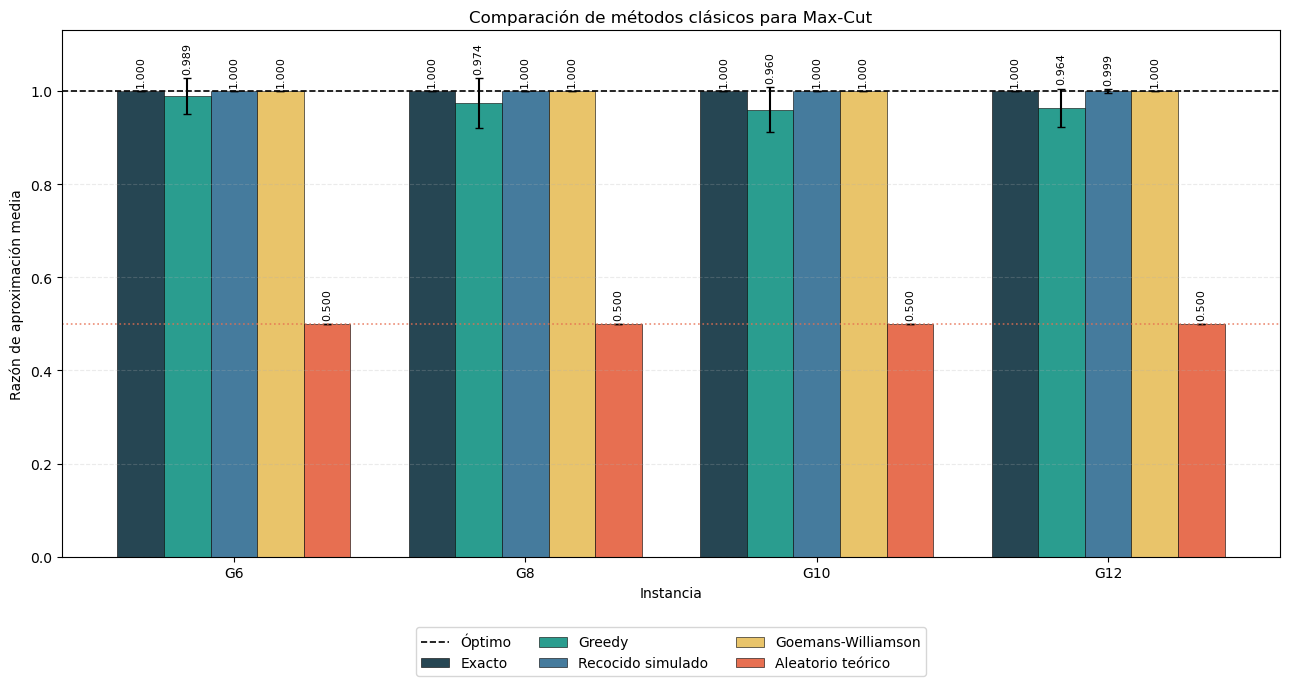

Figura guardada en: /home/jovyan/reto1_qaoa_noir/figuras/comparacion_clasica.png


In [11]:
# Gráfica comparativa de los baselines clásicos

fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(TAMANOS))
ancho = 0.16

colores = {
    "Exacto": "#264653",
    "Greedy": "#2A9D8F",
    "Recocido simulado": "#457B9D",
    "Goemans-Williamson": "#E9C46A",
    "Aleatorio teórico": "#E76F51",
}

for posicion, metodo in enumerate(orden_metodos):
    datos = (
        df_baseline[df_baseline["metodo"] == metodo]
        .sort_values("n")
    )

    razones = datos["razon_media"].to_numpy(dtype=float)

    errores = (
        datos["desviacion"].to_numpy(dtype=float)
        / datos["optimo_exacto"].to_numpy(dtype=float)
    )

    # El método aleatorio teórico no tiene desviación experimental.
    errores = np.nan_to_num(
        errores,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    desplazamiento = (
        posicion - (len(orden_metodos) - 1) / 2
    ) * ancho

    barras = ax.bar(
        x + desplazamiento,
        razones,
        width=ancho,
        yerr=errores,
        capsize=3,
        label=metodo,
        color=colores[metodo],
        edgecolor="black",
        linewidth=0.4,
    )

    ax.bar_label(
        barras,
        labels=[f"{valor:.3f}" for valor in razones],
        padding=3,
        fontsize=8,
        rotation=90,
    )

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Óptimo",
)

ax.axhline(
    0.5,
    color="#E76F51",
    linestyle=":",
    linewidth=1.2,
    alpha=0.8,
)

ax.set_xticks(x)
ax.set_xticklabels([f"G{n}" for n in TAMANOS])

ax.set_ylim(0, 1.13)
ax.set_xlabel("Instancia")
ax.set_ylabel("Razón de aproximación media")
ax.set_title(
    "Comparación de métodos clásicos para Max-Cut"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.24),
    ncol=3,
)

plt.tight_layout()

ruta_figura = (
    FIGURAS / "comparacion_clasica.png"
)

plt.savefig(
    ruta_figura,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print("Figura guardada en:", ruta_figura)

In [12]:
rutas_esperadas = [
    SALIDAS / "baseline_clasico_completo.csv",
    SALIDAS / "verificacion_qubo_g6.csv",
    SALIDAS / "ejecuciones_greedy.csv",
    SALIDAS / "ejecuciones_recocido_simulado.csv",
    SALIDAS / "ejecuciones_goemans_williamson.csv",
    SALIDAS / "resumen_sdp.csv",
    FIGURAS / "comparacion_clasica.png",
]

df_archivos = pd.DataFrame([
    {
        "archivo": str(ruta.relative_to(ROOT)),
        "existe": ruta.exists(),
        "tamano_bytes": (
            ruta.stat().st_size
            if ruta.exists()
            else 0
        ),
    }
    for ruta in rutas_esperadas
])

display(df_archivos)

assert df_archivos["existe"].all(), (
    "Falta al menos un archivo del baseline clásico."
)

assert (df_archivos["tamano_bytes"] > 0).all(), (
    "Existe al menos un archivo vacío."
)

print("Paso 5 completado: todos los archivos existen.")

,archivo,existe,tamano_bytes
0,resultados/clasicos/baseline_clasico_completo.csv,True,2012
1,resultados/clasicos/verificacion_qubo_g6.csv,True,2819
2,resultados/clasicos/ejecuciones_greedy.csv,True,23921
3,resultados/clasicos/ejecuciones_recocido_simul...,True,52003
4,resultados/clasicos/ejecuciones_goemans_willia...,True,152598
5,resultados/clasicos/resumen_sdp.csv,True,232
6,figuras/comparacion_clasica.png,True,144464


Paso 5 completado: todos los archivos existen.
